# KNN Imputer
The **KNN Imputer** is a machine learning-based method for filling in missing values in a dataset by using the values of the k most similar data points (neighbors). It is a multivariate approach that preserves relationships between variables and is more robust than simple methods like mean or median imputation

## How it Works
1. Distance Calculation: For a data point with a missing value, the imputer calculates the distance (typically using the default Euclidean distance, `nan_euclidean_distances`, in scikit-learn) to all other data points in the dataset based on the features that neither point is missing.
> For 2D:
   $$d = \sqrt{weights*(x_2 - x_1)^2 + (y_2 - y_1)^2}$$
> For N-Dimensional:
    $$d(P, Q) = \sqrt{weights*\sum_{i=1}^{n} (q_i - p_i)^2}$$

where weights  = { total no. of coordinates / no. of present coordinates }

2. Neighbor Identification: It identifies the k nearest data points (neighbors) to the point with the missing value. The k (or n_neighbors) is a user-defined hyperparameter, often chosen as the square root of the number of samples.Imputation: The missing value is then replaced with the mean (or weighted average) of the values from these k neighbors for that specific feature

## Key Features and Usage
- Multivariate
- Data-Driven
- Computational Expense

## When to Use KNN Imputer
KNN Imputer is particularly useful when:
- The data has a non-random missingness pattern.
- Relationships between variables are important to preserve.

In [1]:
import matplotlib.pyplot as plt
import numpy as  np
import pandas as pd

from sklearn.model_selection import  train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from  sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("train.csv")[["Age","Pclass",'Fare','Survived']]

df.head()

,Age,Pclass,Fare,Survived
0,22.0,3,7.2500,0
1,38.0,1,71.2833,1
2,26.0,3,7.9250,1
3,35.0,1,53.1000,1
4,35.0,3,8.0500,0


In [3]:
df.isnull().mean()*100

Age         19.86532
Pclass       0.00000
Fare         0.00000
Survived     0.00000
dtype: float64

In [4]:
X = df.drop("Survived",axis=1)
y = df["Survived"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [6]:
X_train.head()

,Age,Pclass,Fare
140,NaN,3,15.2458
439,31.0,2,10.5000
817,31.0,2,37.0042
378,20.0,3,4.0125
491,21.0,3,7.2500


## Knn Imputation
`KNNImputer` has a parameter which called `n_neighbors` is default value is **5**. So on this default value the `accuracy_score is 0.72067` {approx}.

In [7]:
knn = KNNImputer()

X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_trf, y_train)

y_pred = lr.predict(X_test_trf)

accuracy_score(y_test, y_pred)


0.7206703910614525

Now I would check the best `accuracy_score` in all *n_neighbors* so I apply loop which goes `(1, 11)` and calculate all the possible accuracy_score.

In [13]:
accuracy = []
neighbors = []
for i in range (1,11):
    neighbors.append(i)
    knn = KNNImputer(n_neighbors=i)

    X_train_trf = knn.fit_transform(X_train)
    X_test_trf = knn.transform(X_test)

    lr = LogisticRegression()
    lr.fit(X_train_trf, y_train)

    y_pred = lr.predict(X_test_trf)
    accuracy.append(accuracy_score(y_test, y_pred))
    print(f"accuracy at n_neighbors: {i} is {accuracy_score(y_test, y_pred):.5f}")

accuracy at n_neighbors: 1 is 0.73743
accuracy at n_neighbors: 2 is 0.72067
accuracy at n_neighbors: 3 is 0.72626
accuracy at n_neighbors: 4 is 0.72067
accuracy at n_neighbors: 5 is 0.72067
accuracy at n_neighbors: 6 is 0.73184
accuracy at n_neighbors: 7 is 0.72626
accuracy at n_neighbors: 8 is 0.73184
accuracy at n_neighbors: 9 is 0.73184
accuracy at n_neighbors: 10 is 0.72626


Now I plot the accuracy_score to see the difference between them. So I observe that the on *`n_neighbor :1`* the accuracy_score is better than others.

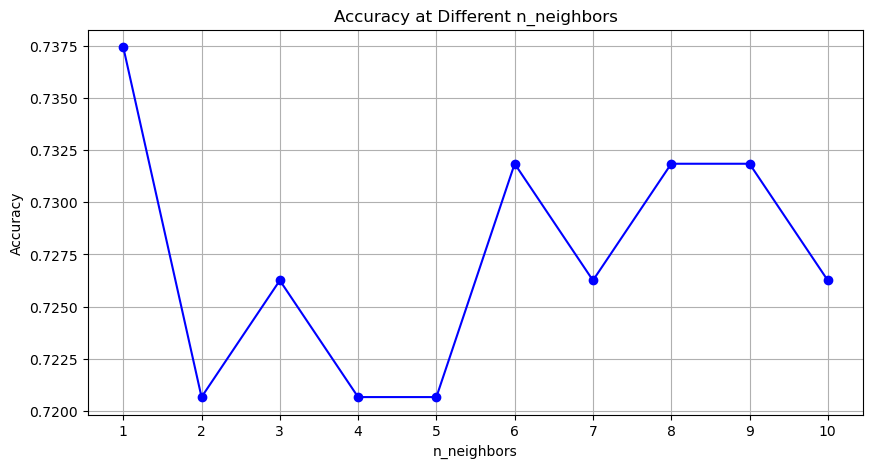

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(neighbors, accuracy, marker='o', linestyle='-', color='b')

# 3. Formatting
plt.title('Accuracy at Different n_neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.xticks(neighbors)
plt.grid(True)

# 4. Display
plt.show()

### Comparison  with Simple Imputer --> mean

In [10]:
si = SimpleImputer()

X_train_si = si.fit_transform(X_train)
X_test_si = si.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_si, y_train)

y_pred2 =  lr.predict(X_test_si)

accuracy_score(y_test, y_pred2)

0.7318435754189944

**Observation: Its shown that the accuracy_score through `KNNImputer` is slightly better than `SimpleImputer`.**